# Preprocessing — Replay-Attack Dataset

Читає `.mov` відео + `.face` файли → кропає обличчя → зберігає кадри на диск.

Результат: `datasets/frames/{train,devel,test}/{real,attack/{fixed,hand}}/{video_name}/frame_XXXX.jpg`

In [11]:
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json

print('OpenCV version:', cv2.__version__)

OpenCV version: 4.13.0


## Конфігурація

In [6]:
DATASET_ROOT   = Path('./datasets')
FRAMES_ROOT    = Path('./datasets/frames')
FACE_LOC_ROOT  = DATASET_ROOT / 'face-locations'

NUM_FRAMES  = 10        # кадрів з кожного відео
FACE_SIZE   = (128, 128)  # розмір збереженого кропу
PADDING     = 0.15      # 15% padding навколо bbox

SPLITS      = ['train', 'devel', 'test']
ATTACK_TYPES = ['fixed', 'hand']

FRAMES_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Кадри зберігатимуться у: {FRAMES_ROOT.resolve()}')

Кадри зберігатимуться у: /Users/darwin/edu/cnn-face-antispoofing-2d/datasets/frames


## Допоміжні функції

In [3]:
def load_face_locations(face_file: Path) -> dict:
    """
    Читає .face файл та повертає словник {frame_id: (x, y, w, h)}.
    Формат рядка: frame_id x y w h
    """
    locations = {}
    if not face_file.exists():
        return locations
    with open(face_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                fid, x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4])
                locations[fid] = (x, y, w, h)
    return locations


def extract_face_frames(video_path: Path, face_locations: dict,
                        num_frames: int = 10,
                        face_size: tuple = (128, 128),
                        padding: float = 0.15) -> list:
    """
    Відкриває відео, рівномірно вибирає num_frames кадрів
    з тих що мають face bbox, кропає та ресайзить обличчя.
    Повертає список (frame_id, bgr_image).
    """
    if not face_locations:
        return []

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'  [!] Не вдалося відкрити: {video_path.name}')
        return []

    valid_fids = sorted(face_locations.keys())

    # рівномірна вибірка
    if len(valid_fids) <= num_frames:
        selected = valid_fids
    else:
        idxs = np.linspace(0, len(valid_fids) - 1, num_frames, dtype=int)
        selected = [valid_fids[i] for i in idxs]

    results = []
    for fid in selected:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
        ret, frame = cap.read()
        if not ret:
            continue

        x, y, w, h = face_locations[fid]
        pad_x = int(padding * w)
        pad_y = int(padding * h)
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(frame.shape[1], x + w + pad_x)
        y2 = min(frame.shape[0], y + h + pad_y)

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_resized = cv2.resize(crop, face_size)
        results.append((fid, crop_resized))

    cap.release()
    return results

## Основний цикл обробки

In [7]:
def process_videos(video_dir: Path, face_loc_dir: Path, out_dir: Path,
                   num_frames: int, face_size: tuple, padding: float):
    """
    Обробляє всі .mov у video_dir, зберігає кадри у out_dir/{video_name}/frame_XXXX.jpg
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    videos = sorted(video_dir.glob('*.mov'))

    ok, skip = 0, 0
    for video_path in tqdm(videos, desc=str(video_dir.relative_to(DATASET_ROOT)), leave=False):
        stem = video_path.stem
        video_out = out_dir / stem

        # пропускаємо якщо вже оброблено
        if video_out.exists() and len(list(video_out.glob('*.jpg'))) >= num_frames:
            skip += 1
            continue

        face_file = face_loc_dir / (stem + '.face')
        face_locs = load_face_locations(face_file)

        frames = extract_face_frames(video_path, face_locs, num_frames, face_size, padding)
        if not frames:
            skip += 1
            continue

        video_out.mkdir(exist_ok=True)
        for fid, img in frames:
            cv2.imwrite(str(video_out / f'frame_{fid:04d}.jpg'), img)
        ok += 1

    return ok, skip


stats = {}

for split in SPLITS:
    print(f'\n=== {split.upper()} ===')
    split_stats = {}

    # --- real ---
    ok, skip = process_videos(
        video_dir   = DATASET_ROOT / split / 'real',
        face_loc_dir= FACE_LOC_ROOT / split / 'real',
        out_dir     = FRAMES_ROOT / split / 'real',
        num_frames=NUM_FRAMES, face_size=FACE_SIZE, padding=PADDING
    )
    split_stats['real'] = {'processed': ok, 'skipped': skip}
    print(f'  real      → оброблено: {ok}, пропущено: {skip}')

    # --- attack/fixed і attack/hand ---
    for atype in ATTACK_TYPES:
        ok, skip = process_videos(
            video_dir   = DATASET_ROOT / split / 'attack' / atype,
            face_loc_dir= FACE_LOC_ROOT / split / 'attack' / atype,
            out_dir     = FRAMES_ROOT / split / 'attack' / atype,
            num_frames=NUM_FRAMES, face_size=FACE_SIZE, padding=PADDING
        )
        split_stats[f'attack/{atype}'] = {'processed': ok, 'skipped': skip}
        print(f'  attack/{atype} → оброблено: {ok}, пропущено: {skip}')

    stats[split] = split_stats

print('\n✅ Preprocessing завершено!')


=== TRAIN ===


  real      → оброблено: 60, пропущено: 0


  attack/fixed → оброблено: 150, пропущено: 0


  attack/hand → оброблено: 150, пропущено: 0

=== DEVEL ===


  real      → оброблено: 60, пропущено: 0


  attack/fixed → оброблено: 150, пропущено: 0


  attack/hand → оброблено: 150, пропущено: 0

=== TEST ===


  real      → оброблено: 80, пропущено: 0


  attack/fixed → оброблено: 197, пропущено: 3


  attack/hand → оброблено: 200, пропущено: 0

✅ Preprocessing завершено!


## Статистика результату

In [8]:
print('\n📊 Підсумок кадрів на диску:\n')
total_frames = 0
for split in SPLITS:
    print(f'  {split}:')
    # real
    real_frames = len(list((FRAMES_ROOT / split / 'real').rglob('*.jpg')))
    real_videos = len([d for d in (FRAMES_ROOT / split / 'real').iterdir() if d.is_dir()]) if (FRAMES_ROOT / split / 'real').exists() else 0
    print(f'    real            → {real_videos} відео, {real_frames} кадрів')
    total_frames += real_frames
    for atype in ATTACK_TYPES:
        p = FRAMES_ROOT / split / 'attack' / atype
        if p.exists():
            atk_frames = len(list(p.rglob('*.jpg')))
            atk_videos = len([d for d in p.iterdir() if d.is_dir()])
            print(f'    attack/{atype}  → {atk_videos} відео, {atk_frames} кадрів')
            total_frames += atk_frames
print(f'\n  ВСЬОГО кадрів: {total_frames}')


📊 Підсумок кадрів на диску:

  train:
    real            → 60 відео, 598 кадрів
    attack/fixed  → 150 відео, 1488 кадрів
    attack/hand  → 150 відео, 1489 кадрів
  devel:
    real            → 60 відео, 600 кадрів
    attack/fixed  → 150 відео, 1480 кадрів
    attack/hand  → 150 відео, 1484 кадрів
  test:
    real            → 80 відео, 792 кадрів
    attack/fixed  → 197 відео, 1952 кадрів
    attack/hand  → 200 відео, 1970 кадрів

  ВСЬОГО кадрів: 11853


## Візуалізація прикладів кадрів

REAL (train):


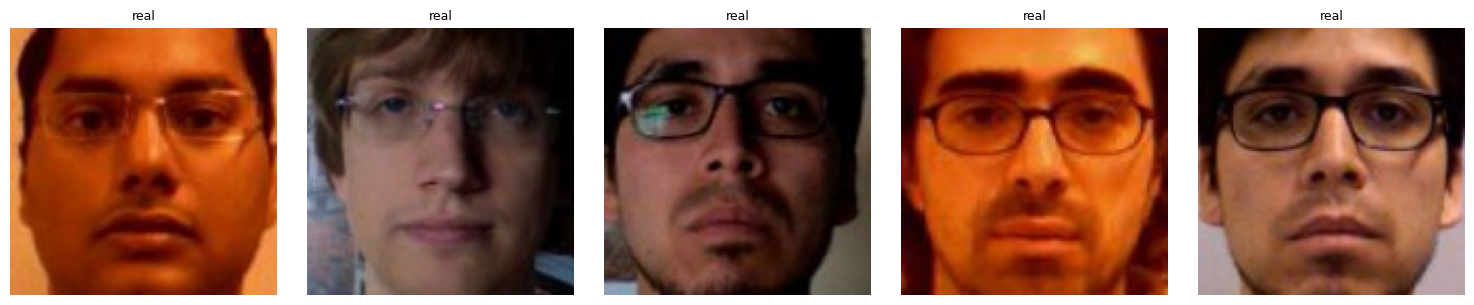

ATTACK fixed (train):


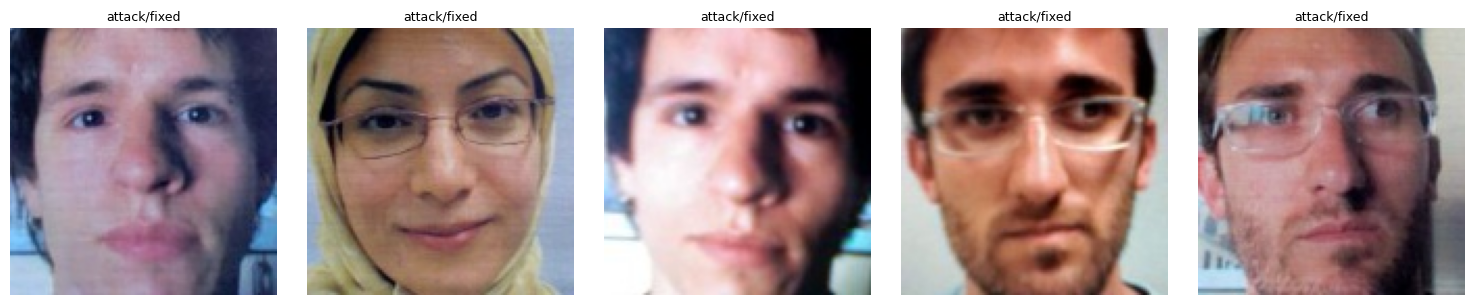

ATTACK hand (train):


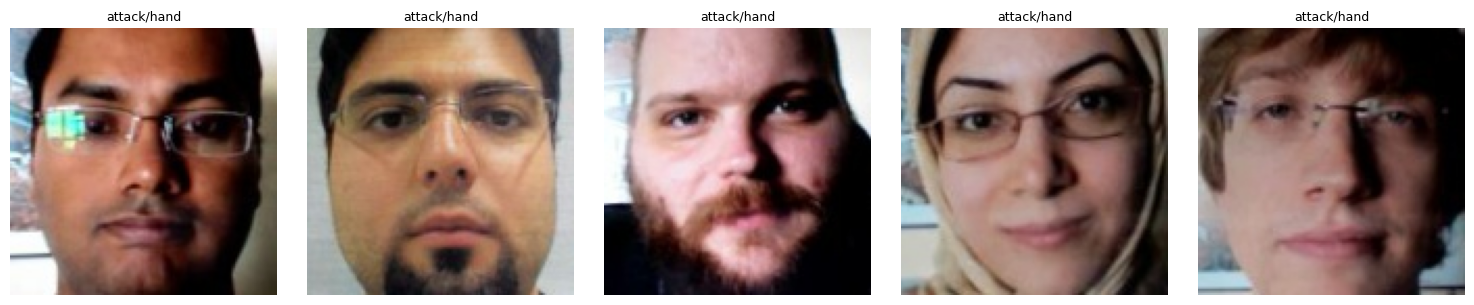

In [9]:
import matplotlib.pyplot as plt
import random

def show_sample_frames(label: str, folder: Path, n: int = 5):
    frames_all = list(folder.rglob('*.jpg'))
    if not frames_all:
        print(f'Немає кадрів у {folder}')
        return
    sample = random.sample(frames_all, min(n, len(frames_all)))
    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for ax, fpath in zip(axes, sample):
        img = cv2.imread(str(fpath))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(label, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('REAL (train):')
show_sample_frames('real', FRAMES_ROOT / 'train' / 'real')

print('ATTACK fixed (train):')
show_sample_frames('attack/fixed', FRAMES_ROOT / 'train' / 'attack' / 'fixed')

print('ATTACK hand (train):')
show_sample_frames('attack/hand', FRAMES_ROOT / 'train' / 'attack' / 'hand')